In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/programmer3/inventory-dataset-for-complex-supply-chains/Inventory_Dataset.csv


In [2]:
# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Load Dataset

In [4]:
df = pd.read_csv('/kaggle/input/datasets/programmer3/inventory-dataset-for-complex-supply-chains/Inventory_Dataset.csv')
df.head()

,date,product_id,warehouse_id,historical_demand,demand_variability,current_inventory,reorder_point,lead_time_days,holding_cost,ordering_cost,shortage_cost,target_operational_cost
0,2022-01-01,1051,2,117,0.320712,240,125,8,3.328840,89.125640,23.859310,888.047353
1,2022-01-02,1092,3,123,0.209622,78,107,6,4.628331,80.445656,12.973182,1025.248670
2,2022-01-03,1014,1,107,0.126077,97,86,5,1.924135,39.398371,9.595929,321.998795
3,2022-01-04,1071,1,122,0.119969,299,183,9,1.477149,61.859766,11.532677,503.527230
4,2022-01-05,1060,4,110,0.146223,275,150,12,0.979533,34.735082,22.055504,304.106651


# Data Cleaning

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     3100 non-null   object 
 1   product_id               3100 non-null   int64  
 2   warehouse_id             3100 non-null   int64  
 3   historical_demand        3100 non-null   int64  
 4   demand_variability       3100 non-null   float64
 5   current_inventory        3100 non-null   int64  
 6   reorder_point            3100 non-null   int64  
 7   lead_time_days           3100 non-null   int64  
 8   holding_cost             3100 non-null   float64
 9   ordering_cost            3100 non-null   float64
 10  shortage_cost            3100 non-null   float64
 11  target_operational_cost  3100 non-null   float64
dtypes: float64(5), int64(6), object(1)
memory usage: 290.8+ KB


date                       0
product_id                 0
warehouse_id               0
historical_demand          0
demand_variability         0
current_inventory          0
reorder_point              0
lead_time_days             0
holding_cost               0
ordering_cost              0
shortage_cost              0
target_operational_cost    0
dtype: int64

# Data Transformation.

In [6]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Sort values
df = df.sort_values(by=['product_id', 'date'])

# Fill missing values
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_57/263371746.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


# Demand Analysis

# Total Cost Analysis

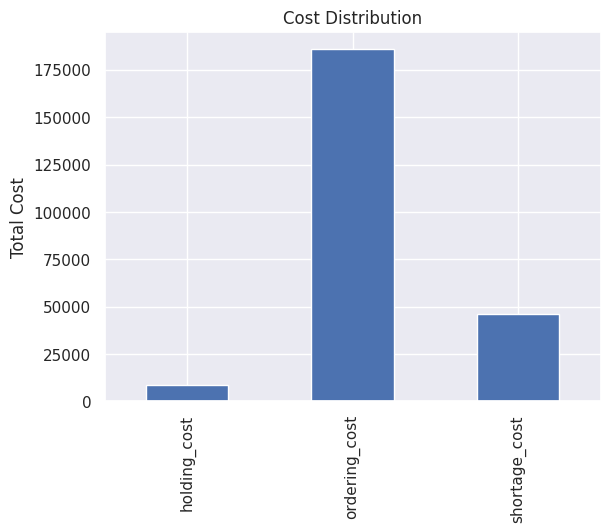

In [7]:
df['total_cost'] = df['holding_cost'] + df['ordering_cost'] + df['shortage_cost']

df[['holding_cost', 'ordering_cost', 'shortage_cost']].sum().plot(kind='bar')
plt.title("Cost Distribution")
plt.ylabel("Total Cost")
plt.show()

# Identify Cost Drivers

In [8]:
cost_summary = df[['holding_cost', 'ordering_cost', 'shortage_cost']].mean()
print(cost_summary)

holding_cost      2.815511
ordering_cost    59.947733
shortage_cost    14.801866
dtype: float64


# Shortage Risk Analysis

In [9]:
# High shortage cost = high risk
high_shortage = df[df['shortage_cost'] > df['shortage_cost'].mean()]

high_shortage.head()

,date,product_id,warehouse_id,historical_demand,demand_variability,current_inventory,reorder_point,lead_time_days,holding_cost,ordering_cost,shortage_cost,target_operational_cost,total_cost
112,2022-04-23,1000,4,138,0.222709,154,137,11,1.536549,48.727711,18.907571,285.356211,69.171830
146,2022-05-27,1000,2,116,0.202794,183,120,5,1.801723,91.409227,20.423634,421.124467,113.634583
192,2022-07-12,1000,2,119,0.177571,395,120,9,2.748030,56.597359,20.947507,1142.069092,80.292897
230,2022-08-19,1000,5,122,0.215175,97,120,11,0.817965,23.365268,17.070211,529.463101,41.253443
491,2023-05-07,1000,5,122,0.389105,329,172,1,4.640071,78.907669,23.028365,1605.491027,106.576105


# Holding vs Shortage Tradeoff

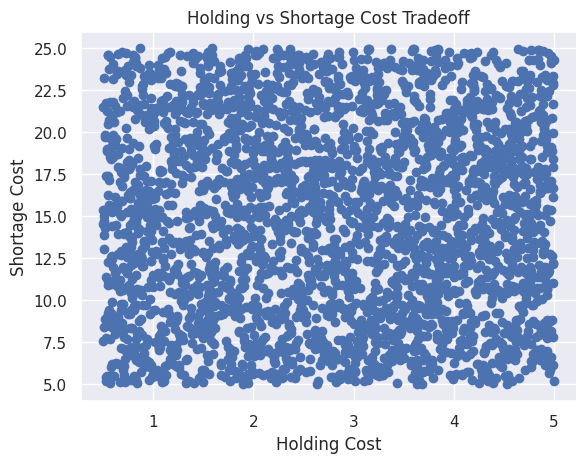

In [10]:
plt.figure()
plt.scatter(df['holding_cost'], df['shortage_cost'])
plt.xlabel("Holding Cost")
plt.ylabel("Shortage Cost")
plt.title("Holding vs Shortage Cost Tradeoff")
plt.show()

#  Ordering Cost Analysis



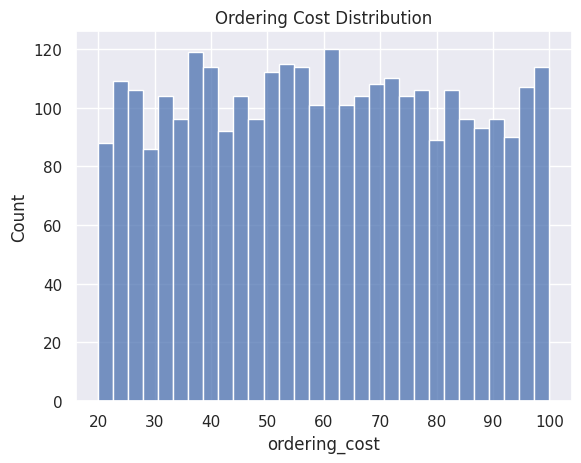

In [11]:
sns.histplot(df['ordering_cost'], bins=30)
plt.title("Ordering Cost Distribution")
plt.show()

# Total Cost Optimization View

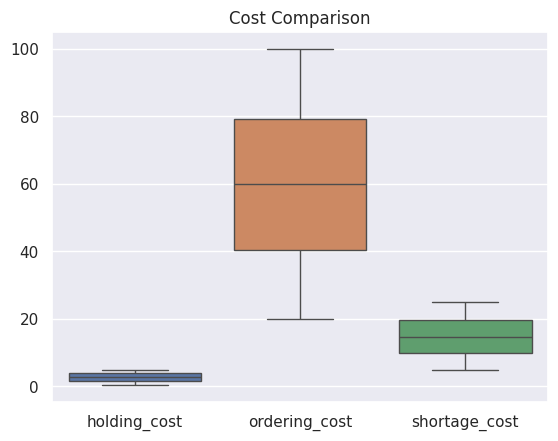

In [12]:
plt.figure()
sns.boxplot(data=df[['holding_cost', 'ordering_cost', 'shortage_cost']])
plt.title("Cost Comparison")
plt.show()

# Correlation


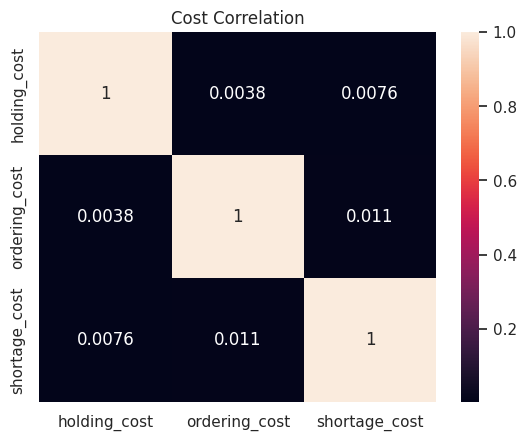

In [13]:
corr = df[['holding_cost', 'ordering_cost', 'shortage_cost']].corr()

sns.heatmap(corr, annot=True)
plt.title("Cost Correlation")
plt.show()

# Inventory Analysis

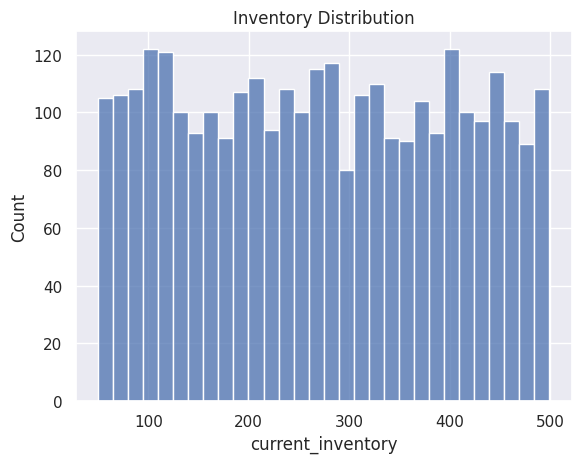

In [14]:
plt.figure()
sns.histplot(df['current_inventory'], bins=30)
plt.title("Inventory Distribution")
plt.show()

# Stockout Analysis

In [15]:
df['stockout'] = df['current_inventory'] < df['historical_demand']

In [16]:
stockout_summary = df.groupby('product_id')['stockout'].mean()

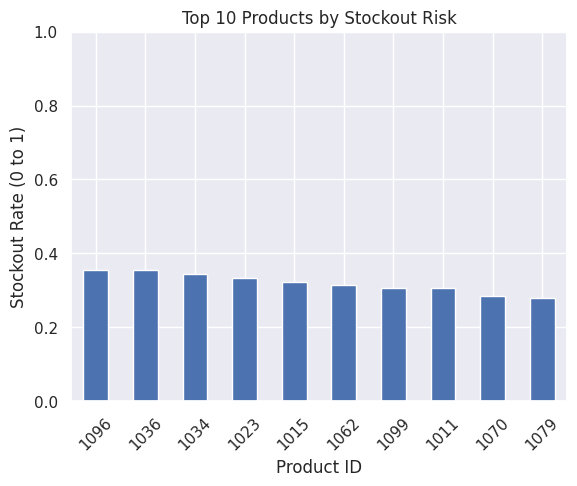

In [17]:
top_risk = stockout_summary.sort_values(ascending=False).head(10)

plt.figure()
top_risk.plot(kind='bar')

plt.title("Top 10 Products by Stockout Risk")
plt.xlabel("Product ID")
plt.ylabel("Stockout Rate (0 to 1)")
plt.xticks(rotation=45)

plt.ylim(0, 1)   # VERY IMPORTANT (fixes scale issue)

plt.show()

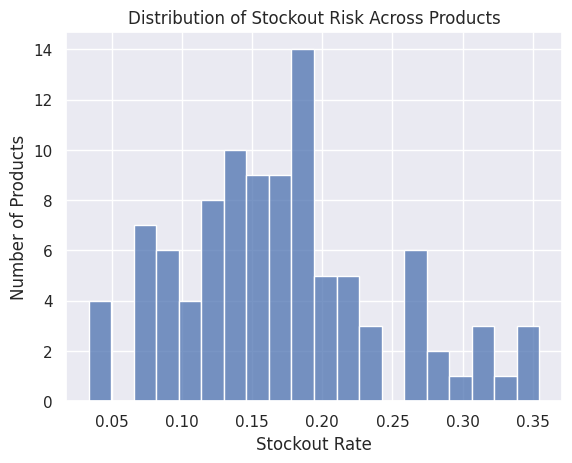

In [18]:
sns.histplot(stockout_summary, bins=20)
plt.title("Distribution of Stockout Risk Across Products")
plt.xlabel("Stockout Rate")
plt.ylabel("Number of Products")
plt.show()

# EOQ

In [19]:
# Annual demand (adjust if your data is daily)
df['annual_demand'] = df['historical_demand'] * 365

# EOQ calculation
df['EOQ'] = np.sqrt(
    (2 * df['annual_demand'] * df['ordering_cost']) / df['holding_cost']
)

df[['product_id', 'EOQ']].head()

,product_id,EOQ
112,1000,1787.375548
146,1000,2072.724002
192,1000,1337.587754
230,1000,1594.995570
274,1000,1578.012917


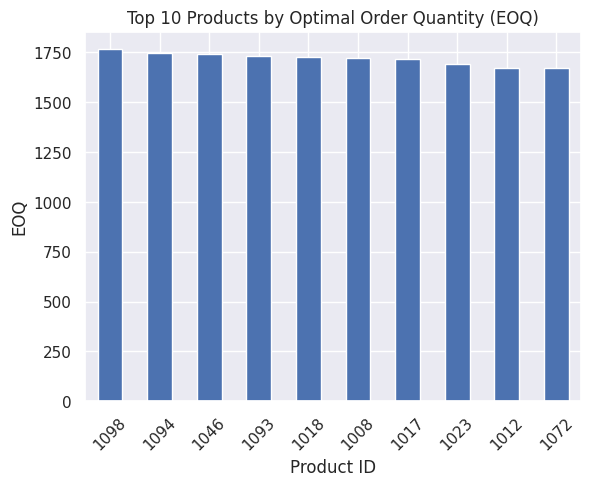

In [20]:
top_products = df.groupby('product_id')['EOQ'].mean().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Optimal Order Quantity (EOQ)")
plt.xlabel("Product ID")
plt.ylabel("EOQ")
plt.xticks(rotation=45)
plt.show()

# SQL ANALYSIS

In [21]:
import sqlite3
conn = sqlite3.connect("Inventory_Dataset.db")  # creates file in working directory
cursor = conn.cursor()
df.to_sql("Inventory_Dataset", conn, if_exists="replace", index=False)

3100

In [22]:
df.to_sql("Inventory_Dataset", conn, if_exists="replace", index=False)

3100

# 1. SERVICE LEVEL ESTIMATION

In [23]:
query =  "SELECT * FROM Inventory_Dataset LIMIT 5";
      

result = pd.read_sql(query, conn)
result

,date,product_id,warehouse_id,historical_demand,demand_variability,current_inventory,reorder_point,lead_time_days,holding_cost,ordering_cost,shortage_cost,target_operational_cost,total_cost,stockout,annual_demand,EOQ
0,2022-04-23 00:00:00,1000,4,138,0.222709,154,137,11,1.536549,48.727711,18.907571,285.356211,69.171830,0,50370,1787.375548
1,2022-05-27 00:00:00,1000,2,116,0.202794,183,120,5,1.801723,91.409227,20.423634,421.124467,113.634583,0,42340,2072.724002
2,2022-07-12 00:00:00,1000,2,119,0.177571,395,120,9,2.748030,56.597359,20.947507,1142.069092,80.292897,0,43435,1337.587754
3,2022-08-19 00:00:00,1000,5,122,0.215175,97,120,11,0.817965,23.365268,17.070211,529.463101,41.253443,1,44530,1594.995570
4,2022-10-02 00:00:00,1000,3,114,0.234786,260,184,3,0.824120,24.659476,11.516936,238.930675,37.000532,0,41610,1578.012917


How well are we meeting demand?

In [24]:
query =  """
 SELECT product_id, 
       SUM(CASE WHEN current_inventory >= historical_demand 
           THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS service_level 
 FROM Inventory_Dataset 
 GROUP BY product_id
 ORDER BY service_level ASC""";

result = pd.read_sql(query, conn)
result
    

,product_id,service_level
0,1036,0.645161
1,1096,0.645161
2,1034,0.656250
3,1023,0.666667
4,1015,0.678571
...,...,...
95,1093,0.933333
96,1080,0.956522
97,1060,0.960000
98,1045,0.965517


# Average Service Level

In [25]:
query= """
SELECT 
    AVG(service_level) AS avg_service_level
FROM (
    SELECT 
        product_id,
        SUM(CASE 
            WHEN current_inventory >= historical_demand THEN 1 
            ELSE 0 
        END) * 1.0 / COUNT(*) AS service_level
    FROM Inventory_Dataset
    GROUP BY product_id
) """
result = pd.read_sql(query, conn)
result

,avg_service_level
0,0.829362


# Service level Distribution

In [26]:


query = """
WITH service_data AS (
    SELECT 
        product_id,
        SUM(CASE 
            WHEN current_inventory >= historical_demand THEN 1 
            ELSE 0 
        END) * 1.0 / COUNT(*) AS service_level
    FROM Inventory_Dataset
    GROUP BY product_id
)

SELECT 
    CASE 
        WHEN service_level < 0.7 THEN 'Low'
        WHEN service_level < 0.9 THEN 'Medium'
        ELSE 'High'
    END AS category,
    COUNT(*) AS num_products
FROM service_data
GROUP BY category
"""

result = pd.read_sql(query, conn)
result


,category,num_products
0,High,17
1,Low,8
2,Medium,75


While the average service level is 82%, distribution analysis shows that 8% of products fall below 70% service level, with some as low as 62–67%, indicating significant underperformance. This highlights that despite a strong overall average, This highlights the need to focus on underperforming products rather than relying solely on aggregate metrics,need for improved inventory planning and safety stock optimization.

# 2. SAFETY STOCK SUGGESTION

How much buffer stock is needed?

In [27]:
query= """
SELECT 
    product_id,
    demand_variability,
    lead_time_days,
    (demand_variability * historical_demand * SQRT(lead_time_days)) AS safety_stock
FROM Inventory_Dataset"""


result = pd.read_sql(query, conn)
result

,product_id,demand_variability,lead_time_days,safety_stock
0,1000,0.222709,11,101.932668
1,1000,0.202794,5,52.601593
2,1000,0.177571,9,63.392893
3,1000,0.215175,11,87.065918
4,1000,0.234786,3,46.359369
...,...,...,...,...
3095,1099,0.419482,1,50.337820
3096,1099,0.317702,9,126.762924
3097,1099,0.493700,11,176.841074
3098,1099,0.154841,13,67.552867


Safety stock requirements vary significantly across products, ranging from approximately 46 to 176 units, indicating differing levels of demand uncertainty and supply delay. Products with higher variability and longer lead times require substantially more buffer stock to prevent stockouts.

# OVERSTOCK DETECTION


Where  is money Stuck in Excess Inventory?




In [28]:
query="""
SELECT 
    product_id,
    warehouse_id,
    current_inventory,
    historical_demand,
    (current_inventory - historical_demand) AS excess_stock
FROM Inventory_Dataset
WHERE current_inventory > historical_demand
ORDER BY excess_stock DESC;""" 

result = pd.read_sql(query, conn)
result


,product_id,warehouse_id,current_inventory,historical_demand,excess_stock
0,1022,5,491,95,396
1,1049,4,486,91,395
2,1016,1,494,102,392
3,1049,5,495,103,392
4,1007,2,493,102,391
...,...,...,...,...,...
2561,1058,3,120,119,1
2562,1061,1,119,118,1
2563,1062,2,107,106,1
2564,1065,1,114,113,1


Excess inventory analysis reveals significant inefficiencies, with some products holding over 390+ units of surplus stock compared to demand. This indicates overstocking of slow-moving items, leading to increased holding costs and capital being locked in non-performing inventory. While some products show minimal excess (1–2 units), the large variation highlights poor demand-inventory alignment and lack of optimized reorder planning.

# FAST V/S SLOW MOVING PRODUCTS

Which Products Move Quickly ?

In [29]:
query="""SELECT 
    MIN(historical_demand) AS min_demand,
    AVG(historical_demand) AS avg_demand,
    MAX(historical_demand) AS max_demand
FROM Inventory_Dataset """
result = pd.read_sql(query, conn)
result

,min_demand,avg_demand,max_demand
0,82,120.255161,159


In [30]:
query = """
WITH demand_data AS (
    SELECT 
        product_id,
        AVG(historical_demand) AS avg_demand
    FROM Inventory_Dataset
    GROUP BY product_id
),

stats AS (
    SELECT 
        AVG(avg_demand) AS mean_demand,
        SQRT(AVG(avg_demand * avg_demand) - AVG(avg_demand) * AVG(avg_demand)) AS std_demand
    FROM demand_data
)

SELECT 
    CASE 
        WHEN avg_demand > mean_demand + std_demand THEN 'Fast Moving'
        WHEN avg_demand < mean_demand - std_demand THEN 'Slow Moving'
        ELSE 'Medium'
    END AS category,
    COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
FROM demand_data, stats
GROUP BY category
"""
result = pd.read_sql(query, conn)
result

,category,percentage
0,Fast Moving,16.0
1,Medium,69.0
2,Slow Moving,15.0


Products are classified based on statistical deviation from average demand, enabling identification of truly high- and low-performing items rather than relying on arbitrary thresholds.

With 69% medium-demand, 16% fast-moving, and 15% slow-moving products, demand is largely stable but uneven. A small fast-moving segment likely drives most revenue, while slow movers risk overstock. This calls for prioritizing availability for high-demand items and reducing inventory for low-demand ones to optimize costs and service levels.

# LEAD TIME RISK ANALYSIS

In [31]:
query="""
SELECT 
    MIN(lead_time_days),
    AVG(lead_time_days),
    MAX(lead_time_days)
FROM Inventory_Dataset"""
result = pd.read_sql(query, conn)
result

,MIN(lead_time_days),AVG(lead_time_days),MAX(lead_time_days)
0,1,7.544516,14


In [32]:
query =  """
WITH lead_time_data AS (
    SELECT 
        product_id,
        AVG(lead_time_days) AS avg_lead_time
    FROM Inventory_Dataset
    GROUP BY product_id
)

SELECT 
    CASE 
        WHEN avg_lead_time > 7.5 THEN 'High Delay Risk'
        ELSE 'Normal'
    END AS risk_level,
    COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
FROM lead_time_data
GROUP BY risk_level
"""
result = pd.read_sql(query, conn)
result

,risk_level,percentage
0,High Delay Risk,52.0
1,Normal,48.0


Lead time analysis shows that 52% of products fall under high delay risk, while 48% operate within normal lead times, indicating that supply chain delays affect a slightly larger portion of the product portfolio.

# COST EFFICIENCY SCORE

Which products are inefficient overall?

In [33]:
query = """SELECT 
    product_id,
    AVG(holding_cost + ordering_cost + shortage_cost) / NULLIF(AVG(historical_demand), 0) AS cost_per_unit
FROM Inventory_Dataset
GROUP BY product_id
ORDER BY cost_per_unit DESC""";
result = pd.read_sql(query, conn)
result

,product_id,cost_per_unit
0,1084,0.746181
1,1094,0.722191
2,1035,0.718135
3,1048,0.716348
4,1050,0.715187
...,...,...
95,1081,0.575734
96,1040,0.573441
97,1067,0.565925
98,1083,0.561021


# Demand_to_reorder_point_ratio

Demand-to-Reorder Point Ratio is a metric that compares average demand to the reorder point to assess how quickly inventory reaches the replenishment threshold.

Demand-to-Reorder Point Ratio= Average Demand/Reorder Point

How often do you need to reorder?

In [34]:
query=""" 
SELECT 
    product_id,
    AVG(historical_demand) / NULLIF(AVG(reorder_point), 0) AS demand_to_reorder_point_ratio
FROM Inventory_Dataset
GROUP BY product_id""";
result = pd.read_sql(query, conn)
result

,product_id,demand_to_reorder_point_ratio
0,1000,0.931373
1,1001,0.855867
2,1002,0.876692
3,1003,0.851972
4,1004,0.826662
...,...,...
95,1095,0.831711
96,1096,0.861250
97,1097,0.852361
98,1098,0.866123


The demand-to-reorder point ratio ranges from approximately 0.81 to 0.93, indicating that for most products, demand remains below the reorder threshold. This suggests that inventory levels are generally sufficient, but may also point to conservative reorder policies leading to potential overstocking.

# DEMAND VOLATILITY SEGMENTATION 

In [35]:
Which products are unpredictable?

Object `unpredictable` not found.


In [36]:
query = """
SELECT 
    product_id,
    AVG(demand_variability) AS variability,
    CASE 
        WHEN AVG(demand_variability) > 0.7 THEN 'Highly Volatile'
        WHEN AVG(demand_variability) > 0.3 THEN 'Moderate'
        ELSE 'Stable'
    END AS volatility_class
FROM Inventory_Dataset
GROUP BY product_id
ORDER BY variability DESC""";
result = pd.read_sql(query, conn)
result

,product_id,variability,volatility_class
0,1008,0.347668,Moderate
1,1069,0.346264,Moderate
2,1084,0.339201,Moderate
3,1058,0.332726,Moderate
4,1064,0.331360,Moderate
...,...,...,...
95,1046,0.262070,Stable
96,1077,0.260823,Stable
97,1097,0.260459,Stable
98,1033,0.254185,Stable


In [37]:
query = """
SELECT MIN(demand_variability), AVG(demand_variability), MAX(demand_variability)
FROM Inventory_Dataset"""
result = pd.read_sql(query, conn)
result

,MIN(demand_variability),AVG(demand_variability),MAX(demand_variability)
0,0.100063,0.298829,0.499538


In [38]:
query = """
WITH volatility_data AS (
    SELECT 
        product_id,
        AVG(demand_variability) AS variability
    FROM Inventory_Dataset
    GROUP BY product_id
)

SELECT 
    CASE 
        WHEN variability > 0.40 THEN 'Highly Volatile'
        WHEN variability > 0.25 THEN 'Moderate'
        ELSE 'Stable'
    END AS volatility_class,
    COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
FROM volatility_data
GROUP BY volatility_class
"""
result = pd.read_sql(query, conn)
result

,volatility_class,percentage
0,Moderate,100.0


Demand variability analysis shows that 100% of products fall within the moderate range, indicating a highly consistent demand pattern across the portfolio with no extreme variability. This suggests that demand behavior is uniform, reducing the need for differentiated inventory strategies based on volatility alone.

# INVENTORY TURNOVER PROXY

How efficiently inventory is used ?

In [39]:
query = """SELECT 
    product_id,
    SUM(historical_demand) / NULLIF(AVG(current_inventory), 0) AS inventory_turnover
FROM Inventory_Dataset
GROUP BY product_id
ORDER BY inventory_turnover DESC""";
result = pd.read_sql(query, conn)
result

,product_id,inventory_turnover
0,1061,21.207389
1,1016,20.527665
2,1062,19.796402
3,1031,19.607129
4,1036,19.547163
...,...,...
95,1030,9.324910
96,1080,9.305344
97,1040,9.249455
98,1082,8.909091


In [40]:
query = """
WITH turnover_data AS (
    SELECT 
        product_id,
        SUM(historical_demand) * 1.0 / NULLIF(AVG(current_inventory), 0) AS inventory_turnover
    FROM Inventory_Dataset
    GROUP BY product_id
)

SELECT 
    MIN(inventory_turnover) AS min_turnover,
    AVG(inventory_turnover) AS avg_turnover,
    MAX(inventory_turnover) AS max_turnover
FROM turnover_data
"""

result = pd.read_sql(query, conn)
result

,min_turnover,avg_turnover,max_turnover
0,7.044739,13.847632,21.207389


Inventory turnover ranges from 7.04 to 21.21, with an average of 13.85, indicating moderate overall inventory efficiency with significant variation across products. This suggests that while some products are highly efficient and fast-moving, others lag behind, creating opportunities for optimization.

In [41]:

query = """
SELECT 
    product_id,
    SUM(historical_demand) * 1.0 / NULLIF(AVG(current_inventory), 0) AS inventory_turnover
FROM Inventory_Dataset
GROUP BY product_id
ORDER BY inventory_turnover DESC
LIMIT 5
"""
high_turnover = pd.read_sql(query, conn)
high_turnover

,product_id,inventory_turnover
0,1061,21.207389
1,1016,20.527665
2,1062,19.796402
3,1031,19.607129
4,1036,19.547163


The top-performing products (IDs 1061, 1016, 1062, 1031, 1036) exhibit very high inventory turnover (~19.5–21.2), indicating rapid sales relative to inventory levels. This reflects strong demand alignment and efficient stock utilization, making these products key revenue drivers for the business.

In [42]:

query = """
SELECT 
    product_id,
    SUM(historical_demand) * 1.0 / NULLIF(AVG(current_inventory), 0) AS inventory_turnover
FROM Inventory_Dataset
GROUP BY product_id
ORDER BY inventory_turnover ASC
LIMIT 5
"""
low_turnover = pd.read_sql(query, conn)
low_turnover

,product_id,inventory_turnover
0,1090,7.044739
1,1082,8.909091
2,1040,9.249455
3,1080,9.305344
4,1030,9.324910


The lowest-performing products (IDs 1090, 1082, 1040, 1080, 1030) show low inventory turnover (~7.0–9.3), indicating slower sales relative to inventory levels. This suggests inefficient stock utilization, where products remain in inventory longer before being sold

# WAREHOUSE LOAD IMBALANCE

In [43]:
Is Inventory evenly Distributed?

Object `Distributed` not found.


In [44]:
query = """
SELECT 
    warehouse_id,
    SUM(current_inventory) AS total_inventory,
    SUM(current_inventory) * 100.0 / SUM(SUM(current_inventory)) OVER () AS percentage_share
FROM Inventory_Dataset
GROUP BY warehouse_id
ORDER BY total_inventory DESC
"""
result = pd.read_sql(query, conn)
result

,warehouse_id,total_inventory,percentage_share
0,3,175355,20.809006
1,4,174002,20.648449
2,1,166826,19.796888
3,5,166786,19.792141
4,2,159719,18.953515


Inventory is relatively evenly distributed across all warehouses, with each holding approximately 19%–21% of total stock. Warehouse 3 holds the highest share (20.8%), while Warehouse 2 holds the lowest (18.95%), indicating a balanced allocation with no major concentration risks.

# Rank products by performance

In [45]:
query="""
SELECT 
    product_id,
    SUM(historical_demand) AS total_demand,
    RANK() OVER (ORDER BY SUM(historical_demand) DESC) AS demand_rank
FROM Inventory_Dataset
GROUP BY product_id;"""
result = pd.read_sql(query, conn)
result

,product_id,total_demand,demand_rank
0,1061,5447,1
1,1098,5208,2
2,1059,5127,3
3,1020,5026,4
4,1091,4961,5
...,...,...,...
95,1030,2583,96
96,1042,2541,97
97,1070,2512,98
98,1082,2401,99


# Track cumulative demand

In [46]:
query = """SELECT 
    date,product_id
    SUM(historical_demand) AS daily_demand,
    SUM(SUM(historical_demand)) OVER (ORDER BY date) AS cumulative_demand
FROM Inventory_Dataset
GROUP BY date,product_id
ORDER BY cumulative_demand DESC LIMIT 5"""

result = pd.read_sql(query, conn)
result

DatabaseError: Execution failed on sql 'SELECT 
    date,product_id
    SUM(historical_demand) AS daily_demand,
    SUM(SUM(historical_demand)) OVER (ORDER BY date) AS cumulative_demand
FROM Inventory_Dataset
GROUP BY date,product_id
ORDER BY cumulative_demand DESC LIMIT 5': near "(": syntax error

# Products worse than average

In [47]:
query = """
SELECT *
FROM Inventory_Dataset
WHERE holding_cost > (
    SELECT AVG(holding_cost) FROM Inventory_Dataset
)"""
result = pd.read_sql(query, conn)
result

,date,product_id,warehouse_id,historical_demand,demand_variability,current_inventory,reorder_point,lead_time_days,holding_cost,ordering_cost,shortage_cost,target_operational_cost,total_cost,stockout,annual_demand,EOQ
0,2023-05-07 00:00:00,1000,5,122,0.389105,329,172,1,4.640071,78.907669,23.028365,1605.491027,106.576105,0,44530,1230.661572
1,2023-12-07 00:00:00,1000,4,124,0.416030,382,92,8,4.838127,95.279914,24.889279,1943.444546,125.007321,0,45260,1335.163051
2,2024-03-17 00:00:00,1000,3,119,0.283507,438,107,9,4.578239,67.581613,13.618629,2072.850111,85.778481,0,43435,1132.400306
3,2024-12-03 00:00:00,1000,4,128,0.169169,272,172,14,4.668862,27.037262,21.274771,1296.967850,52.980896,0,46720,735.600869
4,2025-06-04 00:00:00,1000,3,126,0.385087,130,100,13,3.982544,80.938952,8.769676,598.669674,93.691172,0,45990,1367.241398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1576,2027-05-20 00:00:00,1099,2,119,0.108556,246,129,14,2.820388,56.307982,15.913084,750.123529,75.041455,0,43435,1316.938314
1577,2027-09-04 00:00:00,1099,5,113,0.405208,82,103,9,3.574964,61.281403,6.236305,547.753933,71.092673,1,41245,1189.129463
1578,2028-06-17 00:00:00,1099,1,118,0.180088,192,129,9,4.032105,28.037297,6.720364,802.201398,38.789765,0,43070,773.935208
1579,2029-09-29 00:00:00,1099,3,133,0.317702,113,182,9,4.219178,63.327262,20.429077,948.675888,87.975517,1,48545,1207.170731


# Product + warehouse performance

In [48]:
query= """ 
SELECT 
    warehouse_id,
    product_id,
    SUM(historical_demand) AS total_demand
FROM Inventory_Dataset
GROUP BY warehouse_id, product_id
ORDER BY total_demand DESC LIMIT 5;"""
result = pd.read_sql(query, conn)
result

,warehouse_id,product_id,total_demand
0,3,1092,1798
1,2,1007,1711
2,4,1059,1562
3,3,1058,1559
4,3,1061,1513


# Top product in each warehouse

In [49]:
 query="""
SELECT *
FROM (
    SELECT 
        warehouse_id,
        product_id,
        SUM(historical_demand) AS demand,
        RANK() OVER (PARTITION BY warehouse_id ORDER BY SUM(historical_demand) DESC) AS rank
    FROM Inventory_Dataset
    GROUP BY warehouse_id, product_id
)
WHERE rank = 1;"""
result = pd.read_sql(query, conn)
result

,warehouse_id,product_id,demand,rank
0,1,1004,1406,1
1,2,1007,1711,1
2,3,1092,1798,1
3,4,1059,1562,1
4,5,1014,1456,1


# OUTLIER DETECTION

In [50]:
query=""" 
SELECT *
FROM Inventory_Dataset
WHERE demand_variability > (
    SELECT AVG(demand_variability) + 2 * STDDEV(demand_variability)
    FROM Inventory_Dataset
);"""
result = pd.read_sql(query, conn)
result

DatabaseError: Execution failed on sql ' 
SELECT *
FROM Inventory_Dataset
WHERE demand_variability > (
    SELECT AVG(demand_variability) + 2 * STDDEV(demand_variability)
    FROM Inventory_Dataset
);': no such function: STDDEV